In [61]:
from gerrychain import Graph
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain, proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.tree import recursive_tree_part, bipartition_tree, find_balanced_edge_cuts_memoization
from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias
from gerrychain.updaters import cut_edges

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

from functools import partial
import numpy as np
import csv
import pandas as pd

In [2]:
graph = Graph.from_json("./NC_Processed/output/NC_Processed_Precincts.json")
df = gpd.read_file("./NC_Processed/output/NC_Processed_Precincts.shp")

In [3]:
def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    df["current"] = df["PRECINCTID"].map(partition.assignment)

    counties = sum(df.groupby("COUNTYFP")['current'].nunique()>1)
    return counties

election_names = [
    "PRE",
    "GOV"
]

num_elections = len(election_names)

election_columns = [
  ['G24PRERTRU','G24PREDHAR'],
  ['G24GOVDSTE','G24GOVRROB']
]

my_updaters = {
    "population": updaters.Tally("population", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_NH_Black"] = graph.nodes()[node]["population"] - graph.nodes()[node]["NH_Black"]

my_updaters.update({"NH_Black":Election("NH_Black",{"NH_Black": "NH_Black", "non_NH_Black": "non_NH_Black"})})
my_updaters.update()

# save percentages

my_updaters.update(election_updaters)


In [111]:
ideal_population = df['population'].sum() / 14 # number of congressional districts
cd_dict = recursive_tree_part(graph, range(14), ideal_population, "population",.02)
tree_partition = GeographicPartition(graph, cd_dict, my_updaters)

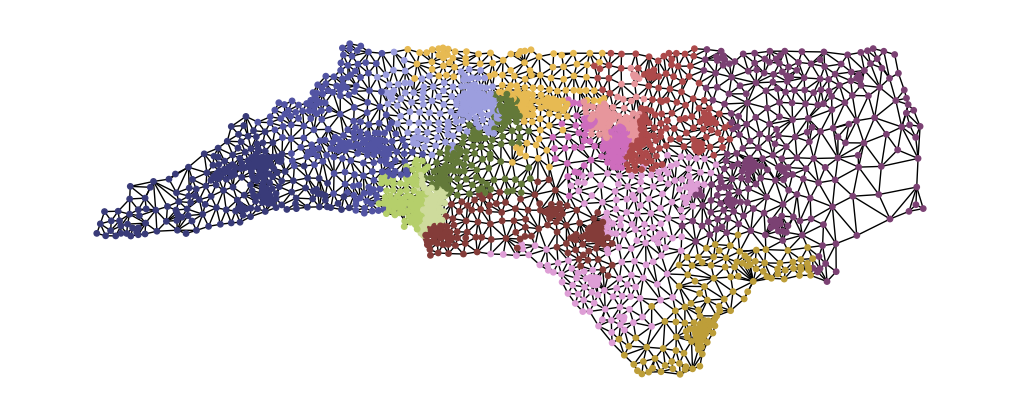

In [112]:
plt.figure(figsize=(10,4))
nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)

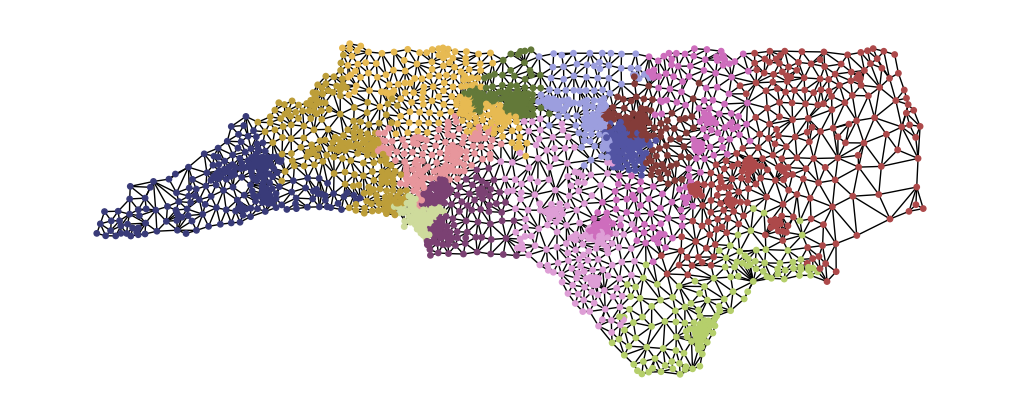

In [99]:
plt.figure(figsize=(10,4))
nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)

In [ ]:
tree_partition['county_splits'] # needs fewer county splits

47

In [8]:
print(sum([1/x for x in polsby_popper(tree_partition).values()])/14)

6.579867209528497


In [14]:
[round((x-ideal_population)/ideal_population,4) for x in tree_partition['population'].values()]

[-0.0092,
 -0.0018,
 0.0093,
 -0.016,
 -0.0008,
 0.018,
 -0.0078,
 0.0101,
 -0.0148,
 0.0168,
 0.0136,
 0.0021,
 -0.0175,
 -0.002]

In [113]:
# w/ new county surcharge that weights edges of counties more

county_proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    region_surcharge = {"COUNTYFP":1}, #adds weight of one to the county edges
    method=partial(bipartition_tree,max_attempts=1000,warn_attempts=1000,allow_pair_reselection=True)
)

second_recom_chain = MarkovChain(
    proposal=county_proposal,
    constraints=[],
    accept=accept.always_accept,
    initial_state=tree_partition,
    total_steps=1000
)

In [95]:
part['county_splits']

11

In [114]:
i = 0
for part in second_recom_chain:
   
    if i%100 == 0:
        print(i)
    if part['county_splits'] < 12 and (sum([1/x for x in polsby_popper(part).values()])/14) > 4:
        break 
    i=i+1


0
100
200
300


In [115]:
import json

ad = dict(part.assignment)

with open("./NC_Seed_Plans/nc_seed_plan5.json", "w") as file:
    json.dump(ad,file)

In [119]:
ads = []
for i in range(1,6):
    with open(f"./NC_Seed_Plans/nc_seed_plan{i}.json","r") as file:
        ads.append(json.load(file))

In [ ]:
# constraints
# Relevant NC metrics: Equal number of representatives (+/- 5% of ideal population)

def pp_constraint(partition):
    return sum([1/x for x in polsby_popper(partition).values()])/14 > 4

def county_constraint(partition):
    return partition['county_splits'] < 13

In [ ]:
print(sum([1/x for x in polsby_popper(GeographicPartition(graph, ads[4],my_updaters)).values()])/14)

3.6956489237586867


In [62]:
CONPart = GeographicPartition(graph, "CON", my_updaters)

In [120]:
seeds = [CONPart, GeographicPartition(graph, ads[0],my_updaters),GeographicPartition(graph, ads[1],my_updaters),GeographicPartition(graph, ads[2],my_updaters),GeographicPartition(graph, ads[3],my_updaters),GeographicPartition(graph, ads[4],my_updaters)]

In [121]:
for seed in range(1,len(seeds)):
    second_recom_chain = MarkovChain(
        proposal = county_proposal,
        constraints=[pp_constraint, county_constraint],
        accept=accept.always_accept,
        initial_state=seeds[5],
        total_steps=100000
    )

    cs = [] # county splits
    mms = [] # mean median
    egs = [] # efficiency gap
    pbs = [] # partisan bias
    dvp = [] # dem voting perc
    pps = [] # polsby popper
    bvp = [] # black voting percent
    mbvp = [] # max black voting percent
    wins = [] # dem wins

    temp = 0
    for part in second_recom_chain:
        temp += 1

        if temp%1000 == 0:
            print(f"seed: {seed} temp: {temp}")
            ad = dict(part.assignment)

            with open("NC_assignment_{seed}_{temp}.json", "w") as file:
                json.dump(ad,file)

            plt.figure(figsize=(10,4))
            nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
            plt.savefig(f'./NC_Markov_gif_3/network_plot_seed{seed}_step{temp}.png')
            plt.close()

            df['current'] = df['PRECINCTID'].map(ad)
            df.plot(column='current', cmap='tab20b')
            plt.axis('off')
            plt.savefig(f'./NC_Markov_gif_3/df_plot_seed{seed}_step{temp}.png')
            plt.close()

            ndf = pd.DataFrame({"County splits":cs, "MM": mms, "EG": egs, "PB": pbs, "DWins": wins, "PP": pps})
            ndf.to_csv(f"./NC_Markov_stats_100000/chain_outputs_{seed}_{temp}.csv")

            with open(f"./NC_Markov_stats_100000/DemPercs_{seed}_{temp}.csv","w") as tf1:
                writer = csv.writer(tf1, lineterminator="\n")
                writer.writerows(dvp)

            with open(f"./NC_Markov_stats_100000/BlackPercs_{seed}_{temp}.csv","w") as tf1:
                writer = csv.writer(tf1, lineterminator="\n")
                writer.writerows(bvp)

            cs = [] # county splits
            mms = [] # mean median
            egs = [] # efficiency gap
            pbs = [] # partisan bias
            dvp = [] # dem voting perc
            pps = [] # polsby popper
            bvp = [] # black voting percent
            mbvp = [] # max black voting percent
            wins = [] # dem wins

        cs.append(part['county_splits'])
        mms.append(mean_median(part['PRE']))
        egs.append(efficiency_gap(part['PRE']))
        pbs.append(partisan_bias(part['PRE']))
        dvp.append(sorted(part['PRE'].percents("Democratic")))
        pps.append(sum([1/x for x in polsby_popper(part).values()])/14)
        bvp.append(sorted(part['NH_Black'].percents("NH_Black")))
        mbvp.append(max(bvp[-1]))
        wins.append(part['PRE'].wins("Democratic"))            

seed: 1 temp: 1000
seed: 1 temp: 2000
seed: 1 temp: 3000
seed: 1 temp: 4000
seed: 1 temp: 5000
seed: 1 temp: 6000
seed: 1 temp: 7000
seed: 1 temp: 8000
seed: 1 temp: 9000
seed: 1 temp: 10000
seed: 1 temp: 11000
seed: 1 temp: 12000
seed: 1 temp: 13000
seed: 1 temp: 14000
seed: 1 temp: 15000
seed: 1 temp: 16000
seed: 1 temp: 17000
seed: 1 temp: 18000
seed: 1 temp: 19000
seed: 1 temp: 20000
seed: 1 temp: 21000
seed: 1 temp: 22000
seed: 1 temp: 23000
seed: 1 temp: 24000
seed: 1 temp: 25000
seed: 1 temp: 26000
seed: 1 temp: 27000
seed: 1 temp: 28000
seed: 1 temp: 29000
seed: 1 temp: 30000
seed: 1 temp: 31000
seed: 1 temp: 32000
seed: 1 temp: 33000
seed: 1 temp: 34000
seed: 1 temp: 35000
seed: 1 temp: 36000
seed: 1 temp: 37000
seed: 1 temp: 38000
seed: 1 temp: 39000
seed: 1 temp: 40000
seed: 1 temp: 41000
seed: 1 temp: 42000
seed: 1 temp: 43000
seed: 1 temp: 44000
seed: 1 temp: 45000
seed: 1 temp: 46000
seed: 1 temp: 47000
seed: 1 temp: 48000
seed: 1 temp: 49000
seed: 1 temp: 50000
seed: 1 t